In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
butanol,74.123,2.7515,3.6139,259.59,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,butanol,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
butanol,H,butanol,e,2544.6,0.006692
co2,H,co2,e,0,0
butanol,H,co2,e,1272.3,0
butanol,e,co2,H,1272.3,0
"""

model = PCSAFT(["co2", "butanol"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 211.97931178468806; 211.97931178468806 259.59]
[2.785e-10 3.19945e-10; 3.19945e-10 3.6139000000000003e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 313.2 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 313.2 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 800.0,
        :guess   => 211.9
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 800.0, :param => :epsilon, :indices => (1, 2), :guess => 211.9, :lower => 10.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_butanol.csv")
fix_line_endings("vley_butanol.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_butanol.csv"
        "vley_butanol.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_butanol.csv
Fixed: vley_butanol.csv
Initial objective value: 0.20962944614210838


In [6]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([201.398879242926], PCSAFT{BasicIdeal, Float64}("co2", "butanol"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 201.398879242926; 201.398879242926 259.59]
[2.785e-10 3.19945e-10; 3.19945e-10 3.6139000000000003e-10]
kij = 0.04041169714728543


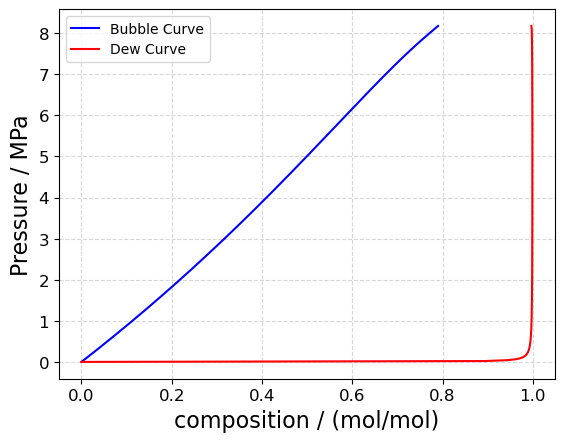

In [9]:
import PyPlot; const plt = PyPlot
using Clapeyron
"""
N = 300
T = 313.15

# 1. Menaikkan rentang batas atas X sedikit (misal ke 0.95 atau 0.98) 
# agar kurva puncak kritisnya bisa terhitung dan menutup sempurna.
x = range(1e-8, 1, length=N)

p = zeros(N)
y = zeros(N)

# Inisialisasi variabel v0 untuk menampung tebakan awal secara kontinu
v0 = []

# 2. Perulangan dengan proteksi try-catch
for j in 1:N
    try
        if j == 1
            # Iterasi pertama menggunakan tebakan default Clapeyron
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]])
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Simpan tebakan awal untuk iterasi berikutnya
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        else
            # Iterasi selanjutnya memanfaatkan nilai v0 dari titik sebelumnya
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]]; v0=v0)
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Perbarui nilai v0 dengan hasil konvergensi terbaru
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        end
    catch e
        # JIKA solver gagal konvergen di dekat titik kritis, titik tersebut 
        # akan diisi dengan NaN (Not a Number) agar kode TIDAK crash/eror,
        # dan grafik Python tetap bisa menggambar bagian yang sukses.
        p[j] = NaN
        y[j] = NaN
    end
end
"""
N    = 401
idxend = N
T    = 313.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]]; v0 = v0)
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

# 3. Bagian pembuatan grafik (Plotting)
plt.clf()
plt.plot(x, p./1e6, color="blue", label="Bubble Curve")
plt.plot(y, p./1e6, color="red", label="Dew Curve")
plt.xlabel("composition / (mol/mol)", fontsize=16)
plt.ylabel("Pressure / MPa", fontsize=16)
plt.xlim()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(true, linestyle="--", alpha=0.5) # opsional: menambahkan grid tipis agar rapi

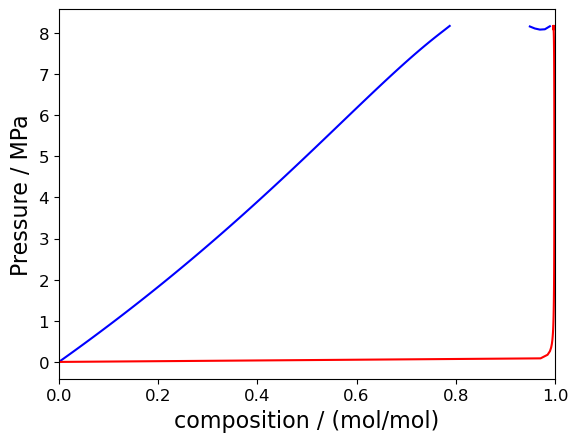

([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], PyCall.PyObject[PyObject Text(0, -1.0, '−1'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 1.0, '1'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 3.0, '3'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 5.0, '5'), PyObject Text(0, 6.0, '6'), PyObject Text(0, 7.0, '7'), PyObject Text(0, 8.0, '8'), PyObject Text(0, 9.0, '9')])

In [23]:
import PyPlot; const plt = PyPlot

N    = 100
T    = 313.2

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [20]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [21]:
aard_p   = calculate_AAD(model_opt, "vlep_butanol.csv", vle_p)


=== AAD: vlep_butanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.4159      6020000.000000  4069178.555860  32.4057 
0.4287      6280000.000000  4210964.973183  32.9464 
0.4441      6490000.000000  4382690.687414  32.4701 
0.4986      6900000.000000  4999306.739533  27.5463 
0.5269      7140000.000000  5323886.539061  25.4358 
0.6031      7520000.000000  6203747.357838  17.5034 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.8744      7960000.000000  11773592.952578  47.9095 
AARD = 30.8881%


30.888149631758647

In [22]:
aard_p   = calculate_AAD(model_opt, "vley_butanol.csv", vle_y)


=== AAD: vley_butanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.4159      0.995400      0.998851      0.3467  
0.4287      0.995900      0.998860      0.2972  
0.4441      0.995500      0.998867      0.3383  
0.4986      0.994900      0.998873      0.3993  
0.5269      0.994300      0.998862      0.4588  
0.6031      0.993100      0.998774      0.5714  


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.8744      0.989300      0.946751      4.3009  
AARD = 0.9589%


0.9589324687476132